In [2]:
!apt-get install swig
!pip install stable-baselines3[extra] gymnasium[box2d]

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  swig4.0
Suggested packages:
  swig-doc swig-examples swig4.0-examples swig4.0-doc
The following NEW packages will be installed:
  swig swig4.0
0 upgraded, 2 newly installed, 0 to remove and 53 not upgraded.
Need to get 1,116 kB of archives.
After this operation, 5,542 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 swig4.0 amd64 4.0.2-1ubuntu1 [1,110 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/universe amd64 swig all 4.0.2-1ubuntu1 [5,632 B]
Fetched 1,116 kB in 0s (3,590 kB/s)
Selecting previously unselected package swig4.0.
(Reading database ... 122403 files and directories currently installed.)
Preparing to unpack .../swig4.0_4.0.2-1ubuntu1_amd64.deb ...
Unpacking swig4.0 (4.0.2-1ubuntu1) ...
Selecting previously unselected package swig.
Preparing to unpack .../swig_4.0.2-1ubu


Task 2 & 3: Melatih DQN dan PPO (CartPole-v1)
[Proses] Memulai pelatihan DQN (50,000 steps)...
[Selesai] Pelatihan DQN selesai dalam 63.87 detik.
[Proses] Memulai pelatihan PPO (50,000 steps)...


/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


[Selesai] Pelatihan PPO selesai dalam 110.28 detik.

Task 4: Menampilkan Plot Pembelajaran (CartPole)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


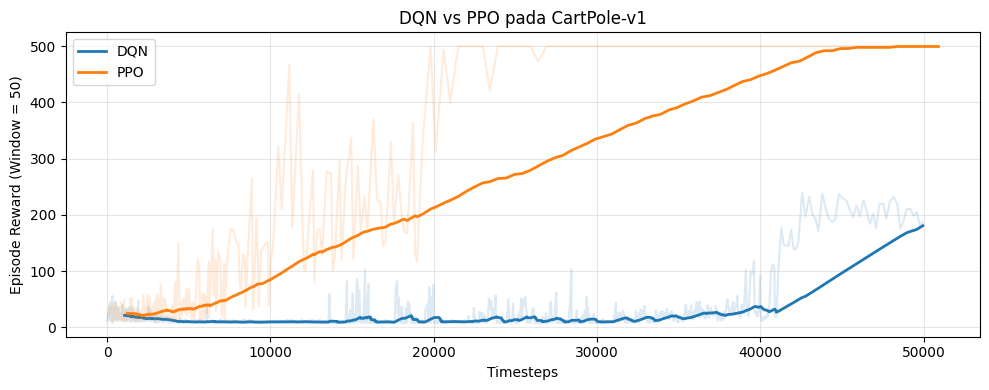


Task 5: Evaluasi Model (10 Episode)
---------------------------------------------
| Algoritma       | Mean Reward | Std        |
---------------------------------------------
| DQN             | 202.80     | 11.54      |
| PPO             | 500.00     | 0.00       |
---------------------------------------------

Task 6: Ablation Study - PPO Gamma=0.9 vs Gamma=0.99
[Proses] Melatih PPO (Gamma=0.90) selama 50,000 steps...


/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


[Selesai] Pelatihan PPO Gamma=0.90 selesai.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


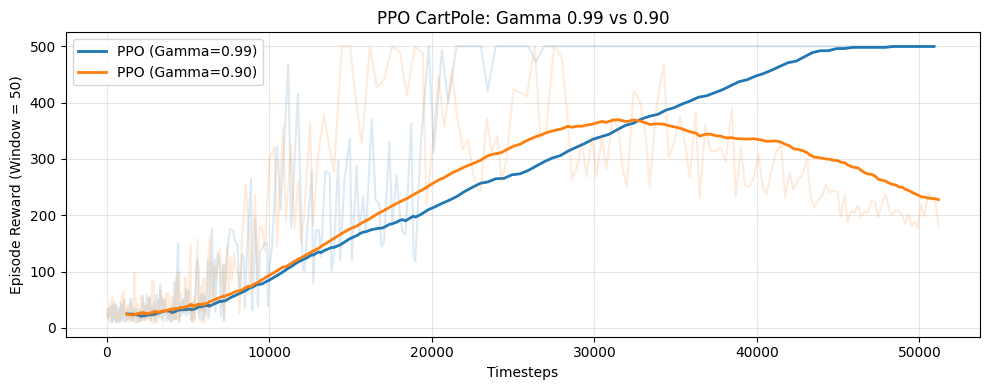


Task 7: Melatih PPO di Lingkungan LunarLander-v3
[Proses] Melatih PPO di LunarLander (200000 steps)...
(Proses ini mungkin membutuhkan waktu 3-5 menit)


<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyPacked has no __module__ attribute
<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyObject has no __module__ attribute
<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type swigvarlink has no __module__ attribute
/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


[Selesai] Pelatihan LunarLander selesai.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


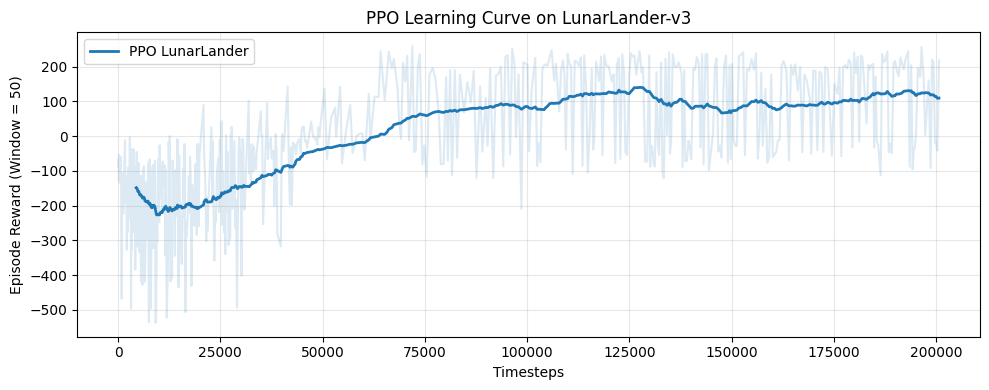

Evaluasi LunarLander (5 episode): Mean Reward = 74.18 ± 115.43
Semua eksekusi Lab 5.1 telah selesai!


In [ ]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
from stable_baselines3 import PPO, DQN
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.results_plotter import load_results

# ==========================================
# Fungsi Bantuan (Helper Functions)
# ==========================================
def create_env(env_id, log_dir):
    """Membuat environment dengan Monitor untuk merekam log plotting."""
    os.makedirs(log_dir, exist_ok=True)
    env = gym.make(env_id)
    return Monitor(env, log_dir)

def evaluate_policy(model, env_id, num_episodes=10):
    """Menjalankan evaluasi model dan mengembalikan mean & std reward."""
    env = gym.make(env_id)
    episode_rewards = []

    for _ in range(num_episodes):
        obs, _ = env.reset()
        done = False
        total_reward = 0
        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, _ = env.step(action)
            total_reward += reward
            done = terminated or truncated
        episode_rewards.append(total_reward)

    env.close()
    return np.mean(episode_rewards), np.std(episode_rewards)

def plot_learning_curves(log_dirs, labels, title, filename, window=50):
    """Membaca log monitor dan membuat plot smoothed learning curve."""
    plt.figure(figsize=(10, 4))
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

    for log_dir, label, color in zip(log_dirs, labels, colors):
        results = load_results(log_dir)
        x = np.cumsum(results.l.values) # Timesteps
        y = results.r.values            # Episode rewards

        # Hitung rolling mean (smoothing)
        y_smooth = np.convolve(y, np.ones(window)/window, mode='valid')

        # Samakan panjang sumbu x dengan y yang sudah dismooth
        x_smooth = x[window - 1:]

        # Plot garis halus (tebal) dan garis asli (transparan)
        plt.plot(x_smooth, y_smooth, label=label, color=color, linewidth=2)
        plt.plot(x, y, color=color, alpha=0.15)

    plt.title(title)
    plt.xlabel("Timesteps")
    plt.ylabel(f"Episode Reward (Window = {window})")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(filename, dpi=150)
    plt.show()

# ==========================================
# Task 2 & 3: Melatih DQN dan PPO (CartPole)
# ==========================================
print("\n" + "="*50)
print("Task 2 & 3: Melatih DQN dan PPO (CartPole-v1)")
print("="*50)

timesteps = 50_000

# 1. Melatih DQN
dqn_log_dir = "./logs/dqn_cartpole"
env_dqn = create_env("CartPole-v1", dqn_log_dir)
model_dqn = DQN("MlpPolicy", env_dqn, verbose=0) # verbose=0 agar log rapi

print("[Proses] Memulai pelatihan DQN (50,000 steps)...")
start_time = time.time()
model_dqn.learn(total_timesteps=timesteps)
dqn_time = time.time() - start_time
model_dqn.save("dqn_cartpole")
print(f"[Selesai] Pelatihan DQN selesai dalam {dqn_time:.2f} detik.")

# 2. Melatih PPO (Gamma = 0.99)
ppo_log_dir = "./logs/ppo_cartpole"
env_ppo = create_env("CartPole-v1", ppo_log_dir)
model_ppo = PPO("MlpPolicy", env_ppo, gamma=0.99, verbose=0)

print("[Proses] Memulai pelatihan PPO (50,000 steps)...")
start_time = time.time()
model_ppo.learn(total_timesteps=timesteps)
ppo_time = time.time() - start_time
model_ppo.save("ppo_cartpole")
print(f"[Selesai] Pelatihan PPO selesai dalam {ppo_time:.2f} detik.")


# ==========================================
# Task 4: Plot DQN vs PPO
# ==========================================
print("\n" + "="*50)
print("Task 4: Menampilkan Plot Pembelajaran (CartPole)")
print("="*50)
plot_learning_curves(
    log_dirs=[dqn_log_dir, ppo_log_dir],
    labels=["DQN", "PPO"],
    title="DQN vs PPO pada CartPole-v1",
    filename="dqn_vs_ppo_cartpole.png"
)


# ==========================================
# Task 5: Evaluasi Model (10 Episode)
# ==========================================
print("\n" + "="*50)
print("Task 5: Evaluasi Model (10 Episode)")
print("="*50)

mean_dqn, std_dqn = evaluate_policy(model_dqn, "CartPole-v1", num_episodes=10)
mean_ppo, std_ppo = evaluate_policy(model_ppo, "CartPole-v1", num_episodes=10)

print("-" * 45)
print(f"| {'Algoritma':<15} | {'Mean Reward':<10} | {'Std':<10} |")
print("-" * 45)
print(f"| {'DQN':<15} | {mean_dqn:<10.2f} | {std_dqn:<10.2f} |")
print(f"| {'PPO':<15} | {mean_ppo:<10.2f} | {std_ppo:<10.2f} |")
print("-" * 45)


# ==========================================
# Task 6: Hyperparameter Ablation (PPO Gamma)
# ==========================================
print("\n" + "="*50)
print("Task 6: Ablation Study - PPO Gamma=0.9 vs Gamma=0.99")
print("="*50)

ppo_gamma09_log_dir = "./logs/ppo_cartpole_gamma09"
env_ppo_09 = create_env("CartPole-v1", ppo_gamma09_log_dir)
model_ppo_09 = PPO("MlpPolicy", env_ppo_09, gamma=0.90, verbose=0)

print("[Proses] Melatih PPO (Gamma=0.90) selama 50,000 steps...")
model_ppo_09.learn(total_timesteps=timesteps)
print("[Selesai] Pelatihan PPO Gamma=0.90 selesai.")

plot_learning_curves(
    log_dirs=[ppo_log_dir, ppo_gamma09_log_dir],
    labels=["PPO (Gamma=0.99)", "PPO (Gamma=0.90)"],
    title="PPO CartPole: Gamma 0.99 vs 0.90",
    filename="ppo_gamma_ablation.png"
)


# ==========================================
# Task 7: Tantangan LunarLander
# ==========================================
print("\n" + "="*50)
print("Task 7: Melatih PPO di Lingkungan LunarLander-v3")
print("="*50)

lunar_timesteps = 200_000
lunar_log_dir = "./logs/ppo_lunarlander"

# Menggunakan parameter dari Listing 2 modul (tapi v3)
env_lunar = create_env("LunarLander-v3", lunar_log_dir)
model_lunar = PPO("MlpPolicy", env_lunar, learning_rate=3e-4,
                  n_steps=2048, batch_size=64, n_epochs=10,
                  gamma=0.99, verbose=0)

print(f"[Proses] Melatih PPO di LunarLander ({lunar_timesteps} steps)...")
print("(Proses ini mungkin membutuhkan waktu 3-5 menit)")
model_lunar.learn(total_timesteps=lunar_timesteps)
model_lunar.save("ppo_lunarlander")
print("[Selesai] Pelatihan LunarLander selesai.")

plot_learning_curves(
    log_dirs=[lunar_log_dir],
    labels=["PPO LunarLander"],
    title="PPO Learning Curve on LunarLander-v3",
    filename="ppo_lunarlander.png"
)

# Evaluasi LunarLander
mean_ll, std_ll = evaluate_policy(model_lunar, "LunarLander-v3", num_episodes=5)
print(f"Evaluasi LunarLander (5 episode): Mean Reward = {mean_ll:.2f} ± {std_ll:.2f}")
print("Semua eksekusi Lab 5.1 telah selesai!")

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


Eksperimen Eksplorasi DQN: eps_end = 0.01 vs 0.1


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


[Proses] Melatih DQN (eps_end = 0.01)...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


[Proses] Melatih DQN (eps_end = 0.10)...

[Selesai] Membuat grafik perbandingan...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


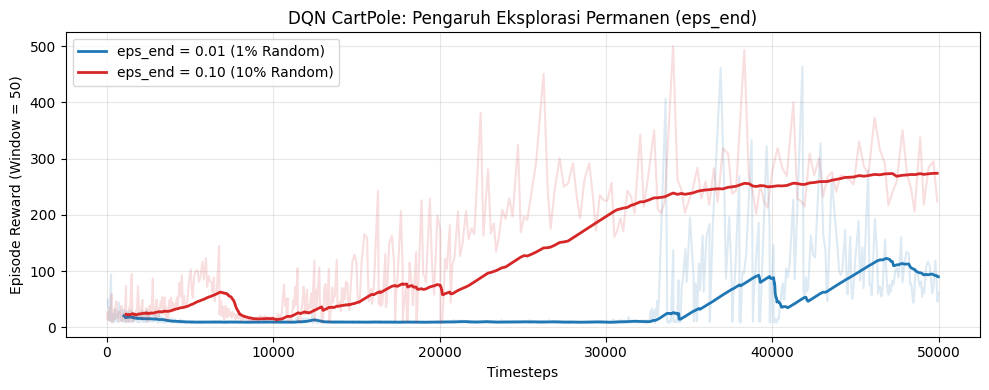


--- Evaluasi Model ---
DQN (eps_end = 0.01) | Mean Reward: 84.3   ± 35.6
DQN (eps_end = 0.10) | Mean Reward: 314.5  ± 70.8


In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
from stable_baselines3 import DQN
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.results_plotter import load_results

def create_env(env_id, log_dir):
    os.makedirs(log_dir, exist_ok=True)
    env = gym.make(env_id)
    return Monitor(env, log_dir)

def plot_dqn_exploration(log_dirs, labels, title, filename, window=50):
    plt.figure(figsize=(10, 4))
    colors = ['#1f77b4', '#d62728'] # Biru dan Merah

    for log_dir, label, color in zip(log_dirs, labels, colors):
        results = load_results(log_dir)
        if len(results) == 0: continue
        x = np.cumsum(results.l.values)
        y = results.r.values

        y_smooth = np.convolve(y, np.ones(window)/window, mode='valid')
        x_smooth = x[window - 1:]

        plt.plot(x_smooth, y_smooth, label=label, color=color, linewidth=2)
        plt.plot(x, y, color=color, alpha=0.15)

    plt.title(title)
    plt.xlabel("Timesteps")
    plt.ylabel(f"Episode Reward (Window = {window})")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(filename, dpi=150)
    plt.show()

def evaluate_dqn(model, title, num_episodes=10):
    env = gym.make("CartPole-v1")
    episode_rewards = []
    for _ in range(num_episodes):
        obs, _ = env.reset()
        done = False
        total_reward = 0
        while not done:
            # Gunakan deterministic=False agar efek epsilon saat evaluasi terlihat
            # (Meski secara default predict dengan deterministic=True akan mengabaikan epsilon,
            # kita ingin melihat seberapa "hancur" model jika epsilon-nya tinggi saat training)
            action, _ = model.predict(obs, deterministic=False)
            obs, reward, terminated, truncated, _ = env.step(action)
            total_reward += reward
            done = terminated or truncated
        episode_rewards.append(total_reward)
    env.close()
    print(f"{title:20} | Mean Reward: {np.mean(episode_rewards):<6.1f} ± {np.std(episode_rewards):.1f}")


print("="*55)
print("Eksperimen Eksplorasi DQN: eps_end = 0.01 vs 0.1")
print("="*55)

timesteps = 50_000

# 1. Melatih DQN dengan eps_end = 0.01 (Eksplorasi Akhir Sangat Rendah)
log_01 = "./logs/dqn_eps_01"
env_01 = create_env("CartPole-v1", log_01)
# Secara default, DQN di SB3 mengecilkan epsilon hingga ke exploration_final_eps
model_01 = DQN("MlpPolicy", env_01, exploration_final_eps=0.01, verbose=0)

print("[Proses] Melatih DQN (eps_end = 0.01)...")
model_01.learn(total_timesteps=timesteps)

# 2. Melatih DQN dengan eps_end = 0.1 (Eksplorasi Akhir Tinggi/10% Random)
log_10 = "./logs/dqn_eps_10"
env_10 = create_env("CartPole-v1", log_10)
model_10 = DQN("MlpPolicy", env_10, exploration_final_eps=0.1, verbose=0)

print("[Proses] Melatih DQN (eps_end = 0.10)...")
model_10.learn(total_timesteps=timesteps)

print("\n[Selesai] Membuat grafik perbandingan...")
plot_dqn_exploration(
    log_dirs=[log_01, log_10],
    labels=["eps_end = 0.01 (1% Random)", "eps_end = 0.10 (10% Random)"],
    title="DQN CartPole: Pengaruh Eksplorasi Permanen (eps_end)",
    filename="dqn_exploration_ablation.png"
)

print("\n--- Evaluasi Model ---")
evaluate_dqn(model_01, "DQN (eps_end = 0.01)")
evaluate_dqn(model_10, "DQN (eps_end = 0.10)")